# 03 - Stage 1 Pre-training (Colab A100)
Run masked generative pre-training for REACT.

## Setup Instructions
Before running this notebook:
1. Upload your data zip to Google Drive at: `MyDrive/REACT/audiocite_data.zip`
   - Zip locally (PowerShell): `Compress-Archive -Path src\data -DestinationPath audiocite_data.zip`
2. Set runtime to **A100 GPU**: Runtime → Change runtime type → A100 GPU
3. Run all cells in order

In [15]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/REACT'
DATA_ZIP  = f'{DRIVE_DIR}/data.zip'
CKPT_DIR  = f'{DRIVE_DIR}/checkpoints/pretrain'

import os
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Expected data zip: {DATA_ZIP}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Expected data zip: /content/drive/MyDrive/REACT/data.zip


In [16]:
# ── Step 2: Clone repo ──────────────────────────────────────────────────
import os
if not os.path.exists('/content/repo'):
    !git clone https://github.com/mohamedzait20003/ECE595NLP-Project /content/repo
else:
    !git -C /content/repo pull origin main
%cd /content/repo
print('Repo ready.')

From https://github.com/mohamedzait20003/ECE595NLP-Project
 * branch            main       -> FETCH_HEAD
Already up to date.
/content/repo
Repo ready.


In [17]:
# ── Step 3: Install dependencies ────────────────────────────────────────
!pip install -q -r requirements.txt
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
print('Dependencies installed.')

Pre-training:   0%|          | 0/20000 [03:47<?, ?step/s]


Dependencies installed.


In [18]:
# ── Step 4: Extract data from Drive ─────────────────────────────────────
import os, json, re
from pathlib import Path

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError(
        f'Data zip not found at {DATA_ZIP}\n'
        'Please upload data.zip to MyDrive/REACT/ in Google Drive.'
    )

print(f'Found: {DATA_ZIP}')
# Extract directly into src/ so data/ lands at src/data/
!unzip -q -o "{DATA_ZIP}" -d /content/repo/src/
print('Zip extracted.')

# Patch Windows absolute paths in manifest JSON files → Colab paths
AUDIO_BASE = '/content/repo/src/data/audio'
target = Path('/content/repo/src/data')

for manifest_name in ['train_manifest.json', 'val_manifest.json', 'test_manifest.json']:
    manifest_path = target / 'audio' / manifest_name
    if not manifest_path.exists():
        continue
    with open(manifest_path, 'r', encoding='utf-8') as f:
        entries = json.load(f)
    patched = 0
    for entry in entries:
        ap = entry.get('audio_path', '')
        if not ap.startswith('/content'):
            parts = re.split(r'[/\\]', ap)
            fname  = parts[-1]
            subdir = parts[-2] if len(parts) >= 2 else manifest_name.split('_')[0]
            entry['audio_path'] = f'{AUDIO_BASE}/{subdir}/{fname}'
            patched += 1
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(entries, f)
    print(f'  Patched {patched} paths in {manifest_name}')

# Verify
print()
for f in ['src/data/audio/train_manifest.json',
          'src/data/audio/val_manifest.json',
          'src/data/processed/train.json']:
    status = 'OK' if os.path.exists(f'/content/repo/{f}') else 'MISSING'
    print(f'  [{status}]  {f}')

Found: /content/drive/MyDrive/REACT/data.zip
Zip extracted.
  Patched 3792 paths in train_manifest.json
  Patched 474 paths in val_manifest.json
  Patched 474 paths in test_manifest.json

  [OK]  src/data/audio/train_manifest.json
  [OK]  src/data/audio/val_manifest.json
  [OK]  src/data/processed/train.json


In [19]:
# ── Step 5: Verify GPU ──────────────────────────────────────────────────
import sys
import torch

sys.path.insert(0, '/content/repo')

assert torch.cuda.is_available(), 'No GPU found! Set runtime to A100.'
print(f'Device : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


In [20]:
# ── Step 6: Configure training (A100 optimized) ─────────────────────────
import yaml
from pathlib import Path

config_path = Path('/content/repo/src/config/pretrain_config.yaml')

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# A100 can handle larger batches and full training
config['training']['fp16'] = True
config['training']['total_steps'] = 20000     # Full training ~1-2h on A100
config['training']['batch_size'] = 8          # A100 has 40GB, can fit 8
config['training']['gradient_accumulation_steps'] = 4  # effective batch = 32
config['training']['checkpoint_dir'] = CKPT_DIR
config['data']['num_workers'] = 4

with open(config_path, 'w') as f:
    yaml.dump(config, f)

print('Config (A100):')
print(f"  total_steps      : {config['training']['total_steps']}")
print(f"  batch_size       : {config['training']['batch_size']}")
print(f"  effective_batch  : {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']}")
print(f"  fp16             : {config['training']['fp16']}")
print(f"  checkpoint       : {config['training']['checkpoint_dir']}")

Config (A100):
  total_steps      : 20000
  batch_size       : 8
  effective_batch  : 32
  fp16             : True
  checkpoint       : /content/drive/MyDrive/REACT/checkpoints/pretrain


In [21]:
# ── Step 7: Run training ────────────────────────────────────────────────
from src.main.training import train
train(str(config_path))

Using device: cuda
Loading Model...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

...

  Step  19950 | loss: 0.1125 | lr: 3.85e-05


Pre-training: 100%|██████████| 20000/20000 [55:47<00:00,  7.27step/s, loss=0.1140, lr=3.85e-05]

  Step  20000 | loss: 0.1140 | lr: 3.85e-05

  [Eval] Step 20000 | val_loss: 3.2381


Pre-training: 100%|██████████| 20000/20000 [56:03<00:00,  5.95step/s, loss=0.1140, lr=3.85e-05]



Training log saved to /content/drive/MyDrive/REACT/checkpoints/pretrain/training_log.json

Stage 1 complete. Best val loss: 2.1257
Checkpoints saved to: /content/drive/MyDrive/REACT/checkpoints/pretrain


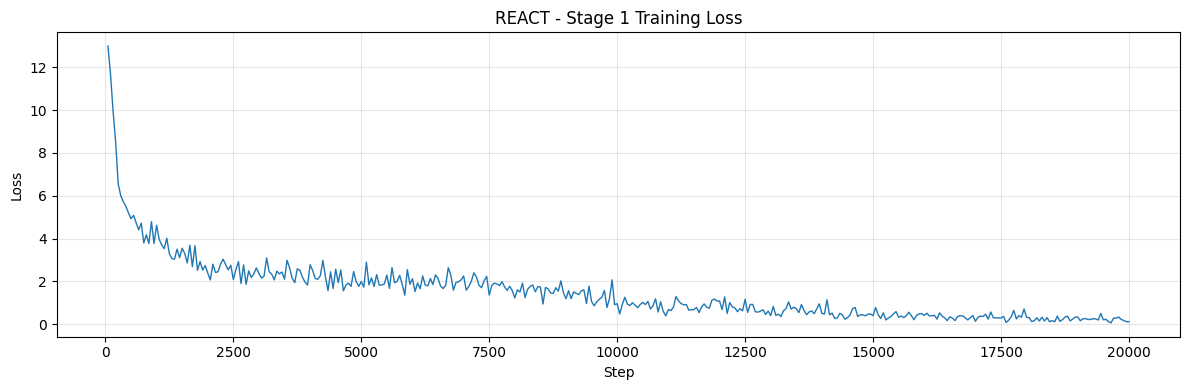

Final loss : 0.1140
Best  loss : 0.0573


In [22]:
# ── Step 8: Plot training loss ──────────────────────────────────────────
import json
import matplotlib.pyplot as plt

log_path = Path(CKPT_DIR) / 'training_log.json'

with open(log_path, 'r') as f:
    history = json.load(f)

steps  = [h['step'] for h in history]
losses = [h['train_loss'] for h in history]

plt.figure(figsize=(12, 4))
plt.plot(steps, losses, linewidth=1)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('REACT - Stage 1 Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final loss : {losses[-1]:.4f}')
print(f'Best  loss : {min(losses):.4f}')

In [ ]:
# ── Step 9: Sanity check on best checkpoint ─────────────────────────────
import torch
from pathlib import Path
from src.main.model.main_model import MainModel
from transformers import BartTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = Path(CKPT_DIR) / 'checkpoint_best.pt'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f'Best checkpoint — step: {ckpt["step"]} | val_loss: {ckpt["val_loss"]:.4f}')

model = MainModel(
    whispher_model='openai/whisper-small',
    bart_model='facebook/bart-base'
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')

ctx = 'A Survey on Natural Language Processing with Deep Learning'
enc = tokenizer(ctx, return_tensors='pt', max_length=128, truncation=True)

dummy_audio = torch.randn(1, 80, 3000).to(device)
text_ids    = enc['input_ids'].to(device)
text_mask   = enc['attention_mask'].to(device)

with torch.no_grad():
    out = model.generate(
        audio_features=dummy_audio,
        text_input_ids=text_ids,
        text_attention_mask=text_mask,
        max_length=32,
        num_beams=3,
    )

print('Generated:', tokenizer.decode(out[0], skip_special_tokens=True))
print('Checkpoints saved to Google Drive at:', CKPT_DIR)